In [ ]:
# # PREDICTION
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
# !cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
# !cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# # Data malaria
# malaria_df = pd.read_excel("data_kasus.xlsx", sheet_name="Malaria")
# tahun_cols = [col for col in malaria_df.columns if str(col).isdigit()]
# malaria_df = malaria_df[["Nama Provinsi"] + tahun_cols]

# # Long format
# malaria_long = pd.melt(malaria_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
# malaria_long["Tahun"] = malaria_long["Tahun"].astype(int)
# malaria_long["Cases"] = pd.to_numeric(malaria_long["Cases"], errors='coerce')
# malaria_long = malaria_long[malaria_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# # DMI & ONI
# dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
# dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

# oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
# oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# # Folder untuk simpan grafik
# os.makedirs("plots", exist_ok=True)

# # Fungsi buat sequence
# def create_sequences(data, n_steps=3):
#     X, y = [], []
#     for i in range(len(data) - n_steps):
#         X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI
#         y.append(data[i+n_steps, 0])     # target: Kasus
#     return np.array(X), np.array(y)
# provinces = malaria_long["Nama Provinsi"].unique()

# for province in provinces:
#     print(f"\nProcessing: {province}")
#     df = malaria_long[malaria_long["Nama Provinsi"] == province].copy()

#     # Gabungkan dengan DMI dan ONI
#     df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
#     df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
#     df.dropna(inplace=True)

#     if len(df) < 5:
#         print(f"Skipping {province} due to insufficient data.")
#         continue

#     # Normalisasi
#     scaler = MinMaxScaler()
#     scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])
#     X, y = create_sequences(scaled, n_steps=3)

#     if len(X) < 1:
#         print(f"Skipping {province} due to insufficient sequences.")
#         continue
# # Train-test split
#     split = int(len(X) * 0.8)
#     X_train, X_test = X[:split], X[split:]
#     y_train, y_test = y[:split], y[split:]
#     n_features = X.shape[2]

#     # LSTM model
#     model = Sequential()
#     model.add(LSTM(8, return_sequences=True, input_shape=(3, n_features)))
#     model.add(Dropout(0.2))
#     model.add(LSTM(24, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(16, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(16, return_sequences=True))
#     model.add(Dropout(0.2))
#     model.add(LSTM(8))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation='linear'))
#     model.compile(optimizer=Adam(), loss='mse')

#     model.fit(X_train, y_train, epochs=100, batch_size=4, verbose=0, validation_data=(X_test, y_test))

#     # Predict
#     y_pred = model.predict(X_test)

#     def inverse_scale(preds, features):
#         combined = np.concatenate((preds, features), axis=1)
#         return scaler.inverse_transform(combined)[:, 0]

#     y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])
#     y_pred_inv = inverse_scale(y_pred, X_test[:, -1])
#     # Save plot
#     plt.figure(figsize=(8, 4))
#     plt.plot(y_test_inv, label="Actual")
#     plt.plot(y_pred_inv, label="Predicted")
#     plt.title(f"Malaria Prediction - {province}")
#     plt.xlabel("Tahun (relative index)")
#     plt.ylabel("Kasus Malaria")
#     plt.legend()
#     plt.grid()
#     plt.tight_layout()
#     filename = province.replace(" ", "_").replace("/", "_")
#     plt.savefig(f"plots/malaria_prediction_{filename}.png")
#     plt.close()

# import os
# os.listdir("plots")


In [ ]:
# PREDICTION
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# Data malaria
malaria_df = pd.read_excel("data_kasus.xlsx", sheet_name="Malaria")
tahun_cols = [col for col in malaria_df.columns if str(col).isdigit()]
malaria_df = malaria_df[["Nama Provinsi"] + tahun_cols]

# Long format
malaria_long = pd.melt(malaria_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
malaria_long["Tahun"] = malaria_long["Tahun"].astype(int)
malaria_long["Cases"] = pd.to_numeric(malaria_long["Cases"], errors='coerce')
malaria_long = malaria_long[malaria_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# DMI & ONI
dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# Folder untuk simpan grafik
os.makedirs("plots", exist_ok=True)

Mounted at /content/drive



Processing: ACEH


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
Final test loss for ACEH: 0.0013

Processing: SUMATERA UTARA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
Final test loss for SUMATERA UTARA: 0.0057

Processing: SUMATERA BARAT


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
Final test loss for MALUKU UTARA: 0.0001

Processing: PAPUA BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
Final test loss for PAPUA BARAT: 0.0095

Processing: PAPUA BARAT DAYA
Skipping PAPUA BARAT DAYA due to insufficient data.

Processing: PAPUA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
Final test loss for PAPUA: 0.2572

Processing: PAPUA SELATAN
Skipping PAPUA SELATAN due to insufficient data.

Processing: PAPUA TENGAH
Skipping PAPUA TENGAH due to insufficient data.

Processing: PAPUA PEGUNUNGAN
Skipping PAPUA PEGUNUNGAN due to insufficient data.

Performance Results Summary:
                Province Model    Train RMSE     Train MAE  Train R2  \
0                   ACEH   12H    886.859501    529.938416 -0.421203   
1         SUMATERA UTARA   12H   5687.567758   4400.092680 -0.124691   
2         SUMATERA BARAT   12H    690.922370    583.651367 -2.358605   
3                   RIAU   12H    429.662376    296.285207  0.453472   
4                  JAMBI   12H   2051.898030   1363.490369 -0.719993   
5       SUMATERA SELATAN   12H   1784.463019   1488.836151 -2.266860   
6               BENGKULU   12H   4294.732854   3018.116289 -0.922469   
7                LAMPUNG   12H   2407.000470   208

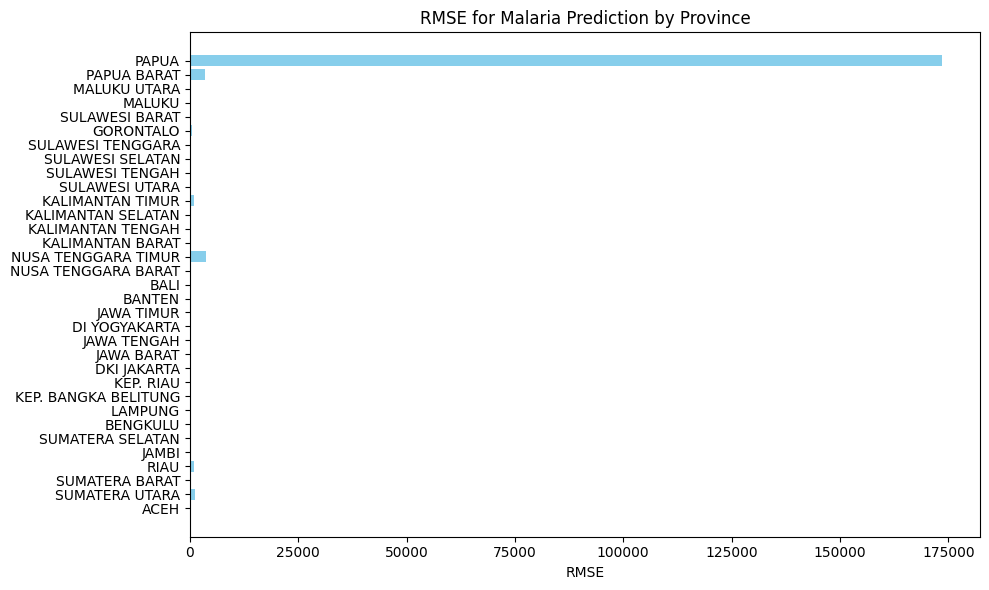

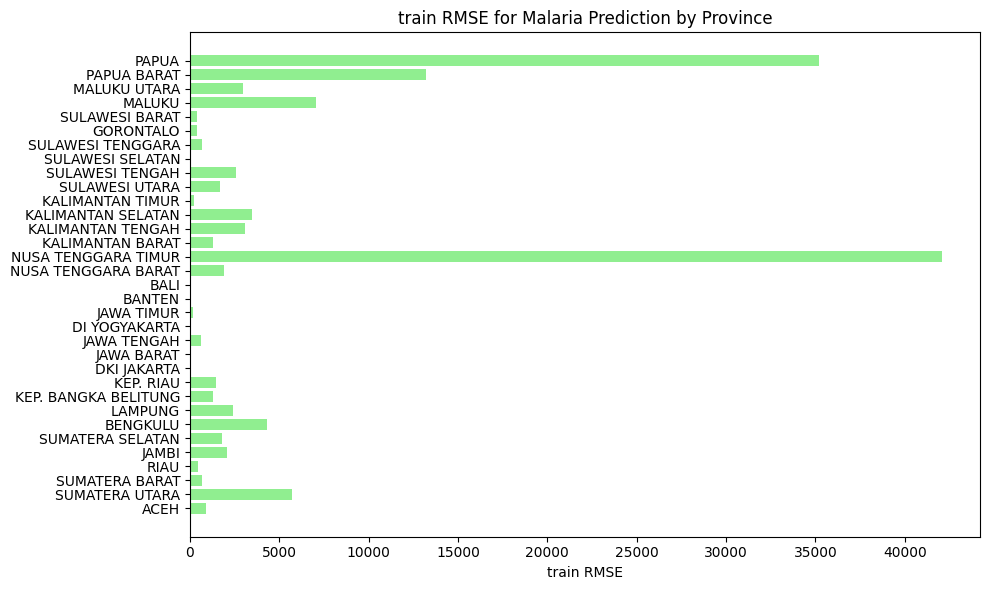

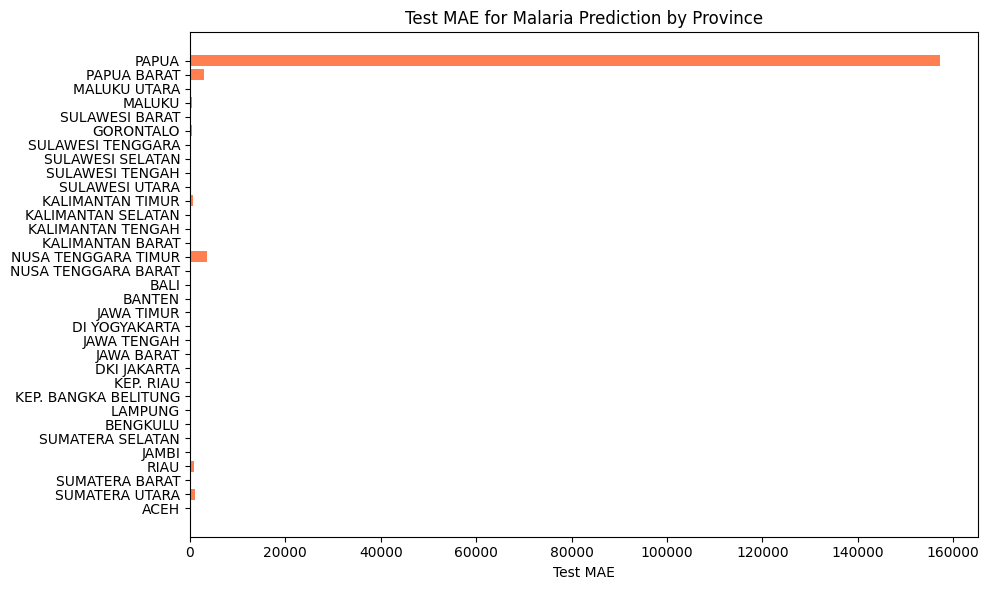

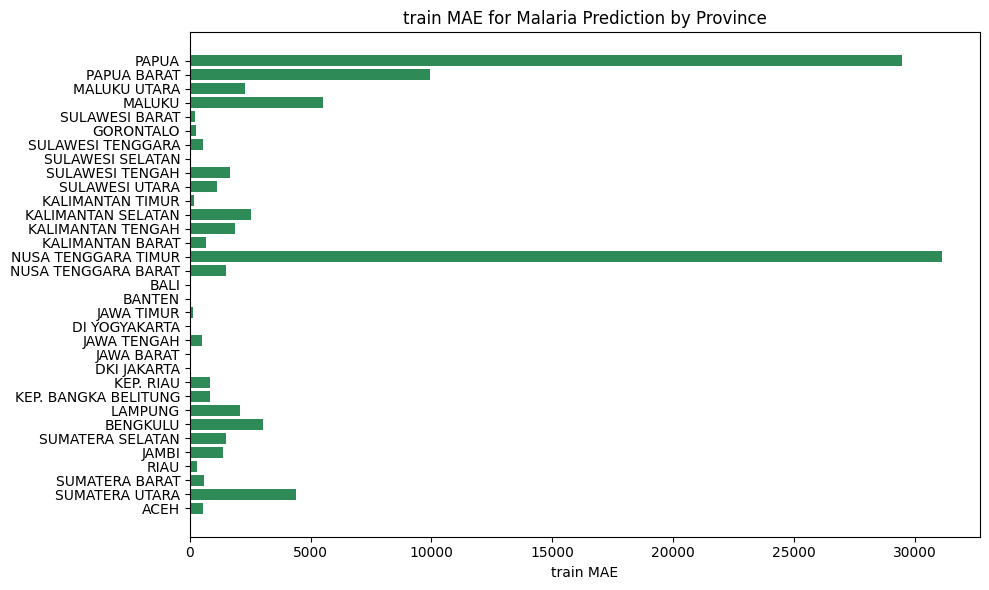

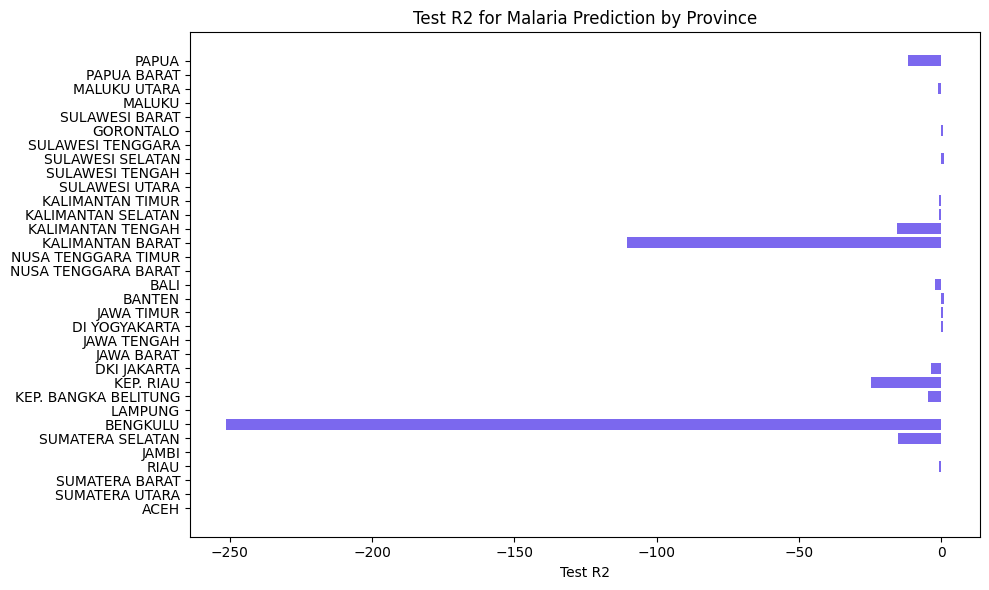

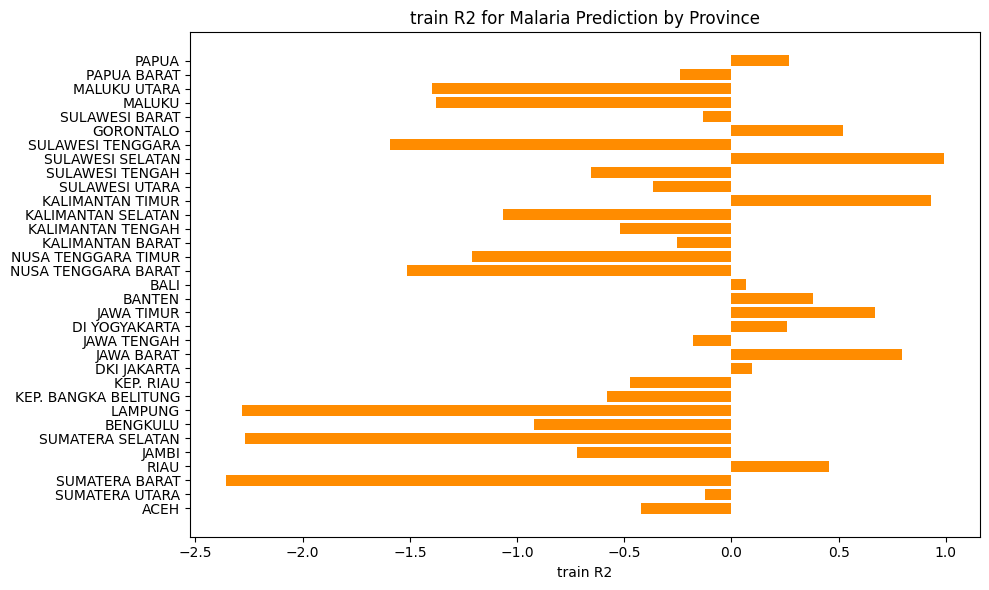

✅ Semua grafik model loss disimpan ke: /content/drive/MyDrive/DATA/plots_loss_malaria


In [ ]:
# # PREDICTION
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
# !cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
# !cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# # Data malaria
# malaria_df = pd.read_excel("data_kasus.xlsx", sheet_name="Malaria")
# tahun_cols = [col for col in malaria_df.columns if str(col).isdigit()]
# malaria_df = malaria_df[["Nama Provinsi"] + tahun_cols]

# # Long format
# malaria_long = pd.melt(malaria_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
# malaria_long["Tahun"] = malaria_long["Tahun"].astype(int)
# malaria_long["Cases"] = pd.to_numeric(malaria_long["Cases"], errors='coerce')
# malaria_long = malaria_long[malaria_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# # DMI & ONI
# dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
# dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

# oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
# oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# # Folder untuk simpan grafik
# os.makedirs("plots", exist_ok=True)

n_steps = 2
# Fungsi buat sequence
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI
        y.append(data[i+n_steps, 0])     # target: Kasus
    return np.array(X), np.array(y)
provinces = malaria_long["Nama Provinsi"].unique()

# RMAE & MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

# Variabel untuk menyimpan metrik evaluasi
performance_results = []
# Variabel untuk menyimpan history pelatihan tiap provinsi
training_histories = {}

for province in provinces:
    print(f"\nProcessing: {province}")
    df = malaria_long[malaria_long["Nama Provinsi"] == province].copy()

    # Gabungkan dengan DMI dan ONI
    df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
    df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
    df.dropna(inplace=True)

    if len(df) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalisasi
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])
    X, y = create_sequences(scaled, n_steps=n_steps)
    def inverse_scale(preds, ref_features):
        dummy = np.zeros((len(preds), 2))
        combined = np.hstack((preds, dummy))
        return scaler.inverse_transform(combined)[:, 0]
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Train-test split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    n_features = X.shape[2]

    # LSTM model
    model = Sequential()
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(24, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=550, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=4000, batch_size=1, verbose=0,callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history  # simpan hasil training

    # Predict on Train
    y_train_pred = model.predict(X_train)
    y_train_inv = inverse_scale(y_train.reshape(-1, 1), X_train[:, -1])
    y_train_pred_inv = inverse_scale(y_train_pred, X_train[:, -1])

    # Predict on Test
    y_test_pred = model.predict(X_test)
    y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])
    y_test_pred_inv = inverse_scale(y_test_pred, X_test[:, -1])

    # Calculate performance metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': '12H',  # This can be adjusted based on the model setup
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })
    # ⬇️ Tambahkan ini di akhir loop provinsi
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final test loss for {province}: {test_loss:.4f}")
# Convert performance results to DataFrame
performance_df = pd.DataFrame(performance_results)

# Save to CSV for further analysis
performance_df.to_csv('performance_results_MALARIA_provinces.csv', index=False)

# Print performance summary in table format
print("\nPerformance Results Summary:")
print(performance_df)

# Optionally, you can save a summary plot (e.g., RMSE comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test RMSE'], color='skyblue')
plt.xlabel('RMSE')
plt.title('RMSE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/rmse_by_province.png')
plt.show()

# Summary plot (RMSE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train RMSE'], color='Lightgreen')
plt.xlabel('train RMSE')
plt.title('train RMSE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_rmse_by_province.png')
plt.show()

# Summary plot (MAE test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test MAE'], color='coral')
plt.xlabel('Test MAE')
plt.title('Test MAE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_mae_by_province.png')
plt.show()

# Summary plot (MAE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train MAE'], color='seagreen')
plt.xlabel('train MAE')
plt.title('train MAE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_mae_by_province.png')
plt.show()

# Summary plot (R2 test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test R2'], color='mediumslateblue')
plt.xlabel('Test R2')
plt.title('Test R2 for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_R2_by_province.png')
plt.show()

# Summary plot (R2 train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train R2'], color='darkorange')
plt.xlabel('train R2')
plt.title('train R2 for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_R2_by_province.png')
plt.show()

import matplotlib.pyplot as plt
import os

# Pastikan folder penyimpanan ada
drive_output_dir = "/content/drive/MyDrive/DATA/plots_loss_malaria"
os.makedirs(drive_output_dir, exist_ok=True)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Buat nama file yang rapi
    filename = prov.replace(" ", "_").replace("/", "_")
    path = os.path.join(drive_output_dir, f"loss_{filename}.png")
    plt.savefig(path)
    plt.close()

print(f"✅ Semua grafik model loss disimpan ke: {drive_output_dir}")


In [ ]:
# Save to CSV for further analysis
performance_df.to_csv('performance_results_provinces.xlsx', index=False)

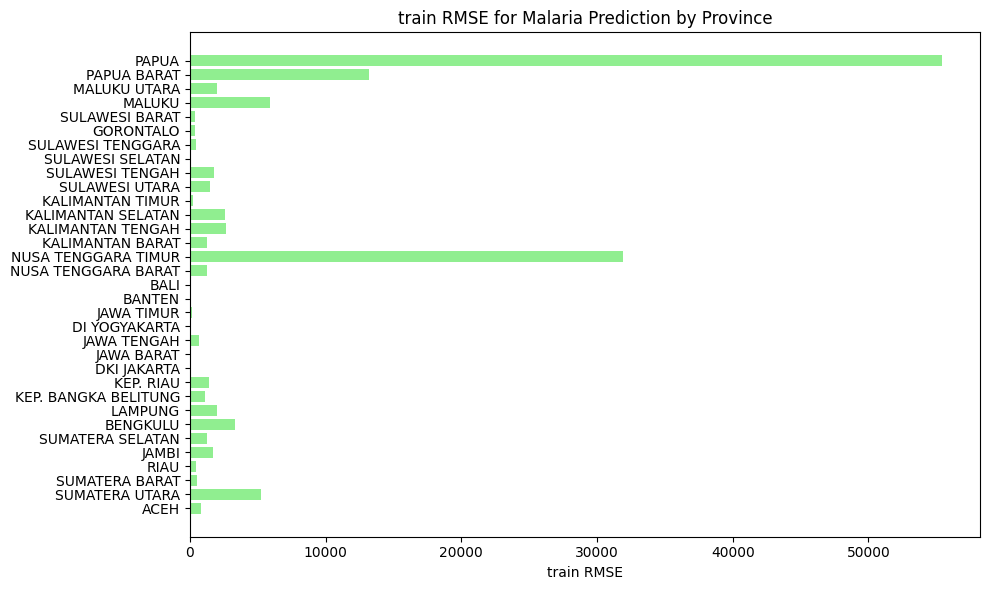

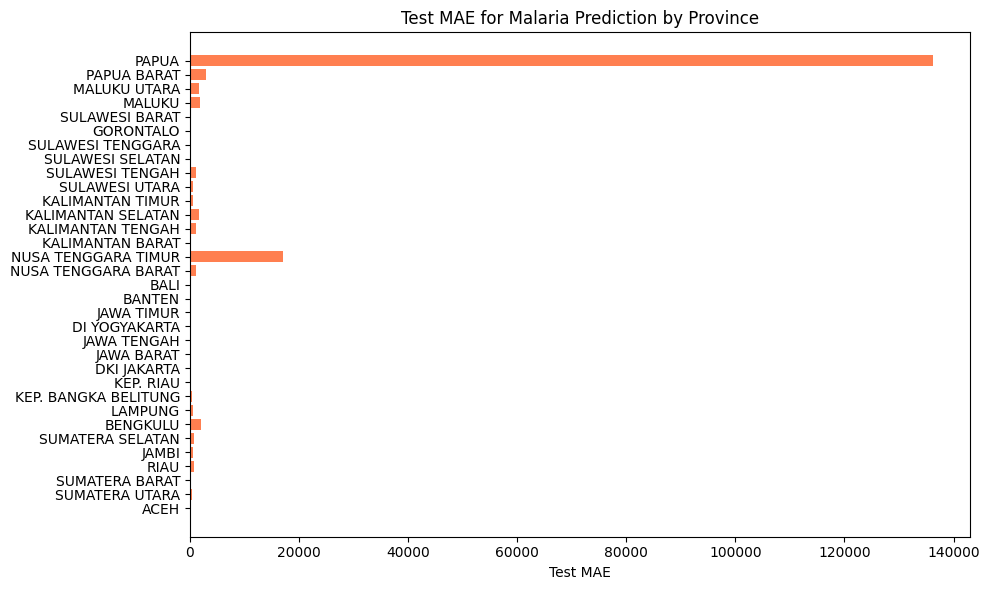

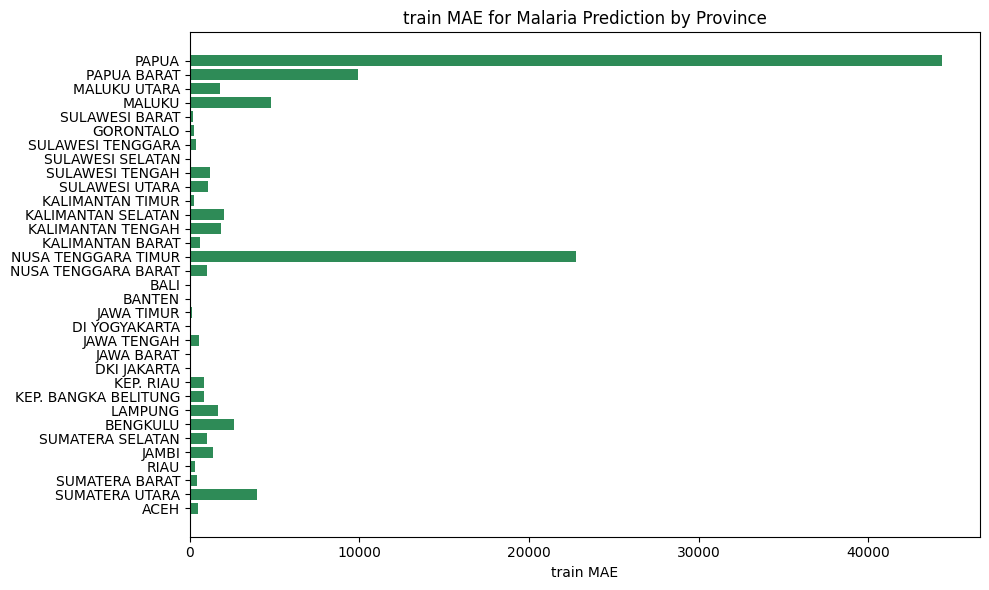

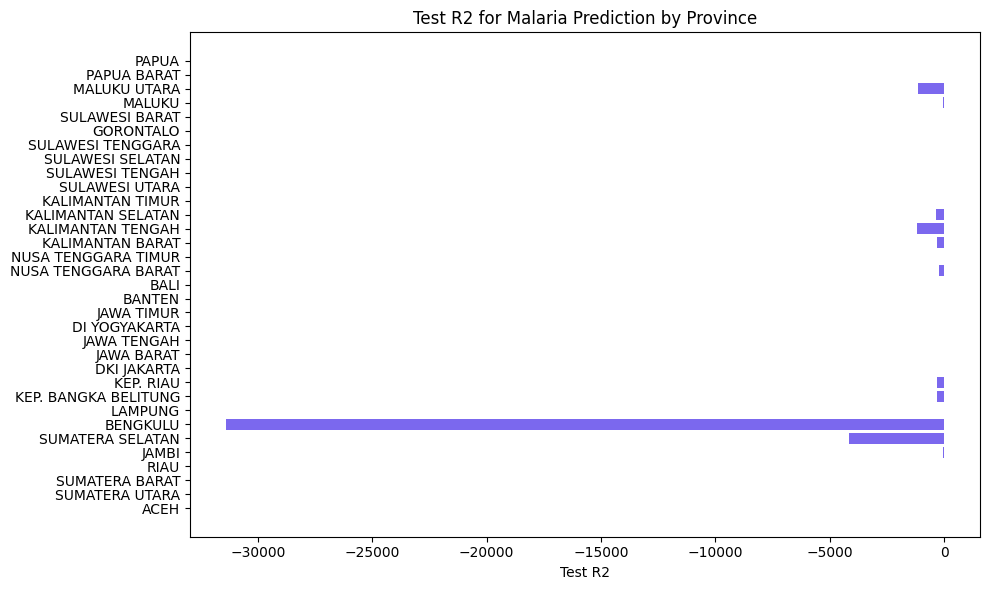

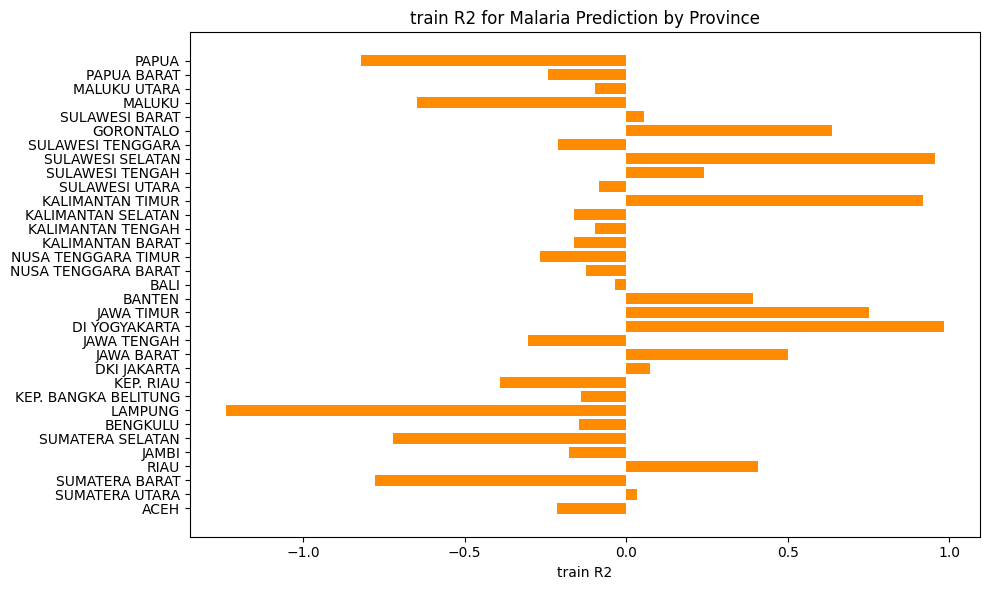

In [ ]:
# Summary plot (RMSE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train RMSE'], color='Lightgreen')
plt.xlabel('train RMSE')
plt.title('train RMSE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_rmse_by_province.png')
plt.show()

# Summary plot (MAE test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test MAE'], color='coral')
plt.xlabel('Test MAE')
plt.title('Test MAE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_mae_by_province.png')
plt.show()

# Summary plot (MAE train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train MAE'], color='seagreen')
plt.xlabel('train MAE')
plt.title('train MAE for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_mae_by_province.png')
plt.show()

# Summary plot (R2 test comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Test R2'], color='mediumslateblue')
plt.xlabel('Test R2')
plt.title('Test R2 for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/test_R2_by_province.png')
plt.show()

# Summary plot (R2 train comparison between provinces)
plt.figure(figsize=(10, 6))
plt.barh(performance_df['Province'], performance_df['Train R2'], color='darkorange')
plt.xlabel('train R2')
plt.title('train R2 for Malaria Prediction by Province')
plt.tight_layout()
plt.savefig('plots/Train_R2_by_province.png')
plt.show()

import matplotlib.pyplot as plt
import os

# Pastikan folder penyimpanan ada
drive_output_dir = "/content/drive/MyDrive/DATA/plots_loss_malaria"
os.makedirs(drive_output_dir, exist_ok=True)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Buat nama file yang rapi
    filename = prov.replace(" ", "_").replace("/", "_")
    path = os.path.join(drive_output_dir, f"loss_{filename}.png")
    plt.savefig(path)
    plt.close()

print(f"✅ Semua grafik model loss disimpan ke: {drive_output_dir}")

In [ ]:
# PREDICTION
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023.xlsx" "./data_kasus.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI.xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"
# Data malaria
malaria_df = pd.read_excel("data_kasus.xlsx", sheet_name="Malaria")
tahun_cols = [col for col in malaria_df.columns if str(col).isdigit()]
malaria_df = malaria_df[["Nama Provinsi"] + tahun_cols]

# Long format
malaria_long = pd.melt(malaria_df, id_vars=["Nama Provinsi"], var_name="Tahun", value_name="Cases")
malaria_long["Tahun"] = malaria_long["Tahun"].astype(int)
malaria_long["Cases"] = pd.to_numeric(malaria_long["Cases"], errors='coerce')
malaria_long = malaria_long[malaria_long["Nama Provinsi"].str.upper() != "INDONESIA"]

# DMI & ONI
dmi_df = pd.read_excel("DMI_pertahun.xlsx").rename(columns=lambda x: x.strip())
dmi_df = dmi_df.rename(columns={dmi_df.columns[1]: "DMI"}).set_index("Year").sort_index()

oni_df = pd.read_excel("ONI_3.xlsx").rename(columns=lambda x: x.strip())
oni_df = oni_df.rename(columns={oni_df.columns[1]: "ONI"}).set_index("YEAR").sort_index()
# Folder untuk simpan grafik
os.makedirs("plots", exist_ok=True)

n_steps = 2
# Fungsi buat sequence
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # input: DMI & ONI
        y.append(data[i+n_steps, 0])     # target: Kasus
    return np.array(X), np.array(y)
provinces = malaria_long["Nama Provinsi"].unique()

# RMAE & MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

# Variabel untuk menyimpan metrik evaluasi
performance_results = []
# Variabel untuk menyimpan history pelatihan tiap provinsi
training_histories = {}

for province in provinces:
  if province   == "PAPUA":
    print(f"\nProcessing: {province}")
    df = malaria_long[malaria_long["Nama Provinsi"] == province].copy()

    # Gabungkan dengan DMI dan ONI
    df = df.merge(dmi_df[["DMI"]], left_on="Tahun", right_index=True, how="left")
    df = df.merge(oni_df[["ONI"]], left_on="Tahun", right_index=True, how="left")
    df.dropna(inplace=True)

    if len(df) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalisasi
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[["Cases", "DMI", "ONI"]])
    X, y = create_sequences(scaled, n_steps=n_steps)
    def inverse_scale(preds, ref_features):
        dummy = np.zeros((len(preds), 2))
        combined = np.hstack((preds, dummy))
        return scaler.inverse_transform(combined)[:, 0]
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Train-test split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    n_features = X.shape[2]

    # LSTM model
    model = Sequential()
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(8, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(4))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=0.3), loss='mse')

    # Train model
    early_stop = EarlyStopping(monitor='val_loss', patience=700, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=6000, batch_size=1, verbose=0,callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history  # simpan hasil training

    # Predict on Train
    y_train_pred = model.predict(X_train)
    y_train_inv = inverse_scale(y_train.reshape(-1, 1), X_train[:, -1])
    y_train_pred_inv = inverse_scale(y_train_pred, X_train[:, -1])

    # Predict on Test
    y_test_pred = model.predict(X_test)
    y_test_inv = inverse_scale(y_test.reshape(-1, 1), X_test[:, -1])
    y_test_pred_inv = inverse_scale(y_test_pred, X_test[:, -1])

    # Calculate performance metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': '12H',  # This can be adjusted based on the model setup
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })
    # ⬇️ Tambahkan ini di akhir loop provinsi
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final test loss for {province}: {test_loss:.4f}")
# Convert performance results to DataFrame
performance_df = pd.DataFrame(performance_results)

# Save to CSV for further analysis
performance_df.to_csv('performance_results_MALARIA_provinces.csv', index=False)

# Print performance summary in table format
print("\nPerformance Results Summary:")
print(performance_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: PAPUA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Final test loss for PAPUA: 0.0545

Performance Results Summary:
  Province Model     Train RMSE      Train MAE  Train R2     Test RMSE  \
0    PAPUA   12H  118327.765838  110961.602456 -7.289877  79940.576871   

     Test MAE  Test R2  
0  63451.9531 -1.70286  
